In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [70]:
data = pd.read_csv('./new_dataset/dataset_for_EDA.csv', sep = ',', encoding='latin1')

In [71]:
#list(data.columns)

In [72]:
pred_col = [#'participant',
#'timestamp',
#'clinical-timestamp',
#'sis-01',
#'sis-02',  
#'sis-03',
#'sis-04',
#'sis-05',
#'sis-06',
#'sis',   ## response num
#'ohs-01',
#'ohs-02',
#'ohs-03',
#'ohs-04',
#'ohs-05',
#'ohs-06',
#'ohs-07',
#'ohs-08',
#'ohs-09',
#'ohs-10',
#'ohs-11',
#'ohs-12',
#'ohs',    ## response num
#'oks-01',
#'oks-02',
#'oks-03',
#'oks-04',
#'oks-05',
#'oks-06',
#'oks-07',
#'oks-08',
#'oks-09',
#'oks-10',
#'oks-11',
#'oks-12',
#'oks',   ## response num
#'tug',
#'chairstand',
#'acceleration-count',    ### correlation between acceleration-count and acceleration-sum : 0.9951972186352874
'acceleration-mean',
'acceleration-std',
'acceleration-sum',
'acceleration-entropy',
'acceleration-kurtosis',
#'acceleration-skew',    ### correlation between acceleration-kurtosis and acceleration-skew : 0.8125826802627331
#'acceleration-coefficient-of-variation',   ### correlation between acceleration-std and acceleration-coefficient-of-variation : 0.9981691376357329
'acceleration-minutes-with-data',
#'acceleration-hours-with-data',    ### correlation between acceleration-minutes-with-data and acceleration-hours-with-data : 0.9641458619672144
'acceleration-movement-events-00to06',
'acceleration-movement-events-06to12',
'acceleration-movement-events-12to18',
'acceleration-movement-events-18to24',
'acceleration-movement-events-24h',
'acceleration-intradaily-variability',
#'heartrate-count',               ### correlation between heartrate-count and step-count : 0.876279182684799
'heartrate-min',
'heartrate-max',
'heartrate-mean',
'heartrate-std',
#'heartrate-hours-with-data',            ### correlation between heartrate-hours-with-data and step-ratio : 0.8663971705294171
'motion-count',
'motion-ratio',
#'motion-mean',      ### correlation between motion-count and motion-mean : 0.9857676696532148   (prefer total per day than average[motion per hour] in the day)
#'motion-max',       ### correlation between motion-count and motion-max : 0.8091784342142361
'motion-max-timestamp',
#'position-count',    ### correlation between position-count and position-duration : 0.8047174777969475
'position-duration',
'position-distance-travelled',
'sleep-total',
'sleep-deep',
#'sleep-light',    ### correlation between sleep-total and sleep-light : 0.7930157798362605
'sleep-rem',
'sleep-snoring',
'sleep-duration-to-sleep',
'sleep-duration-to-wakeup',
'sleep-wakeup-count',
'sleep-heartrate-mean',
'sleep-heartrate-min',
#'sleep-heartrate-max',    ### correlation between sleep-heartrate-mean and sleep-heartrate-max : 0.7302037341830914
'step-count',
'step-ratio',
#'step-mean',             ### correlation between step-mean and step-count : 0.9205297140077597
#'step-max',              ### correlation between step-count and step-max : 0.9586093567130545   (prefer total steps per day than max[steps per hour] in the day))
'step-max-timestamp',
'age',
'sex_male',
'education_label',
'work_part_time',
#'fracture_femur fracture',  ### VIF high (BASELINE)
'fracture_hip fracture',
'fracture_hip replacement',
'fracture_pelvis fracture',
'ethnicity_black',
#'ethnicity_caucasian',   correlation between ethnicity_black and ethnicity_caucasian : -0.7905694150420951 (BASELINE)
'ethnicity_south asian'
#'SISS_Category_Q',   ## response class quartile
#'OHSS_Category_Q',   ## response class quartile
#'OKSS_Category_Q'   ## response class quartile
]

In [73]:
col_resp = ['sis', 'ohs', 'oks', 'SISS_Category_Q', 'OHSS_Category_Q', 'OKSS_Category_Q']

In [74]:
corr_col  = [x for x in pred_col if x not in col_resp]

for column_1 in corr_col:
    #print(column_1)
    for column_2 in corr_col:
        df_1 = data[column_1]
        df_2 = data[column_2]
        correlation = df_1.corr(df_2)
        if abs(correlation) > 0.7 and abs(correlation) < 0.99999:
            print('correlation between ' + column_1 + ' and ' + column_2 + ' : ' + str(correlation))

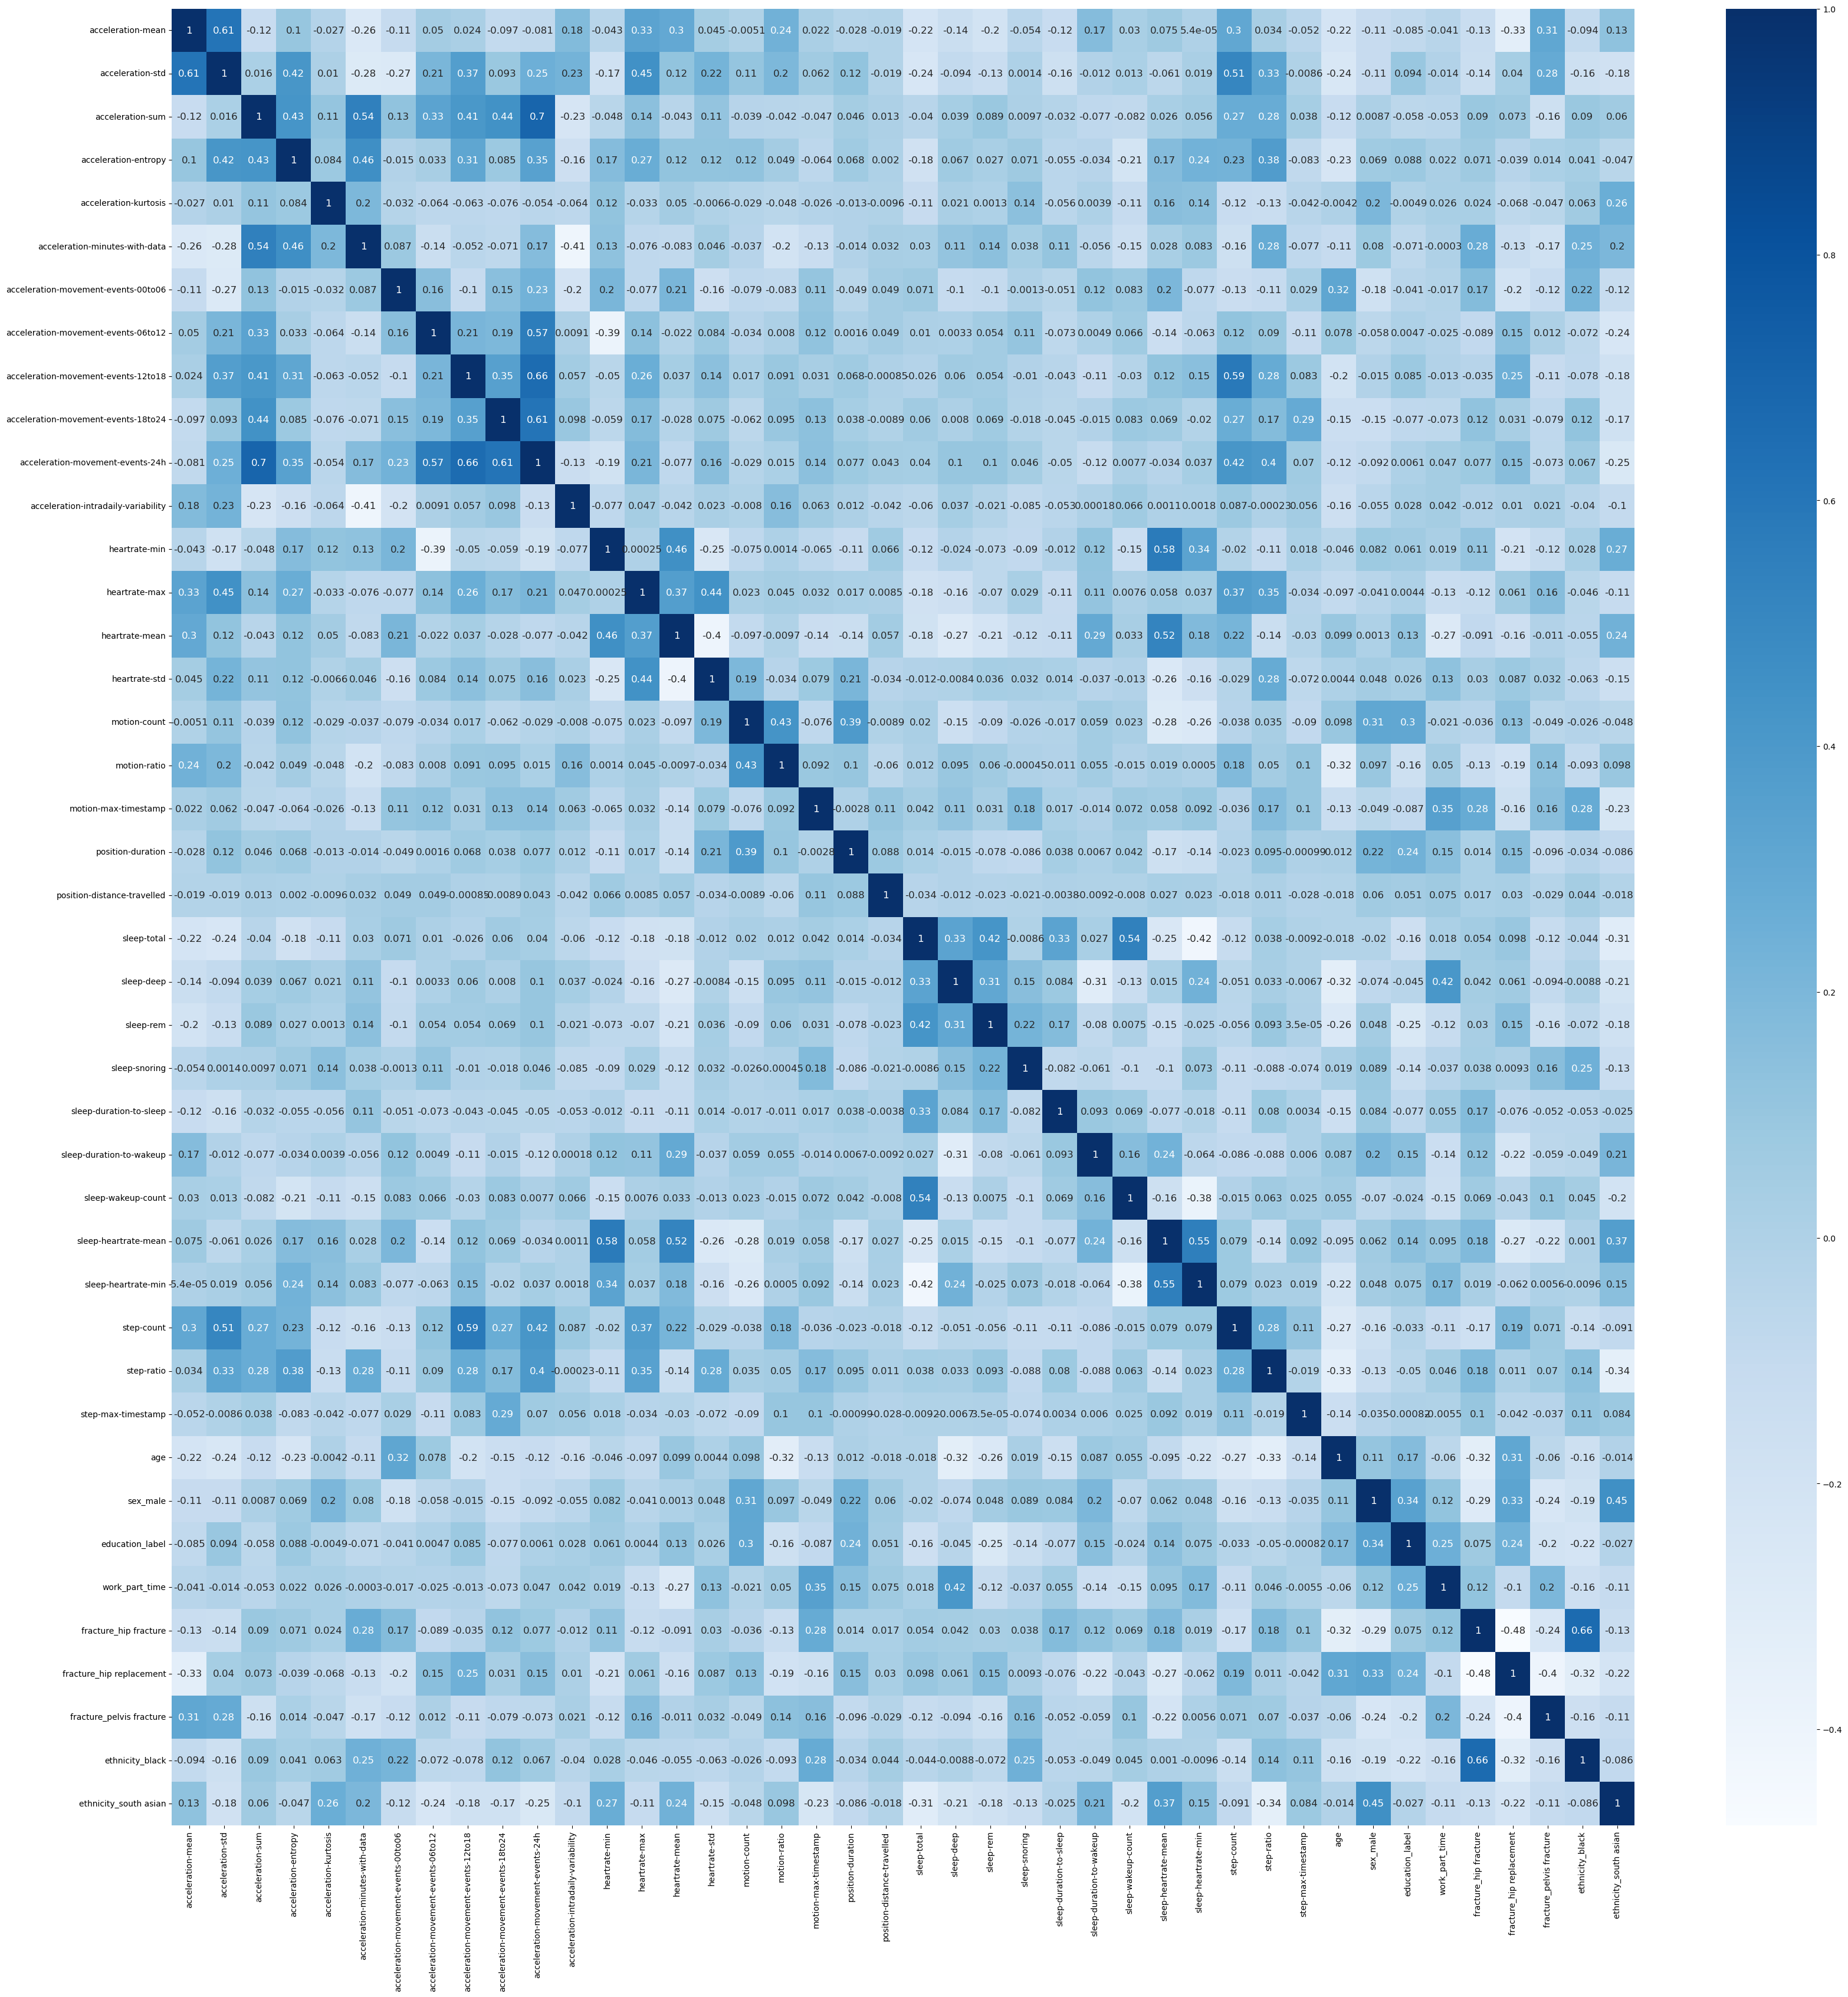

In [75]:
plt.figure(figsize=(40,40))
sns.heatmap(data[corr_col].corr(), cmap="Blues", annot=True, annot_kws={"size": 12} )
# Salva direttamente come PDF
#plt.savefig("heatmap.pdf", format="pdf", bbox_inches="tight")
# Chiude la figura per evitare sovrapposizioni in nuovi plot
plt.show()

In [76]:
Predictors = data[corr_col]

X = Predictors
# VIF dataframe 
vif_data = pd.DataFrame() 
vif_data["feature"] = X.columns 
# calculating VIF for each feature 
vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                          for i in range(len(X.columns))]
vif_data

,feature,VIF
0,acceleration-mean,615.824031
1,acceleration-std,13.154651
2,acceleration-sum,19.893085
3,acceleration-entropy,156.513440
4,acceleration-kurtosis,1.530951
5,acceleration-minutes-with-data,31.126789
6,acceleration-movement-events-00to06,3.589443
7,acceleration-movement-events-06to12,7.676468
8,acceleration-movement-events-12to18,9.598629
9,acceleration-movement-events-18to24,6.230040


In [ ]:
#tmp_list = corr_col + col_resp

In [80]:
df = data[corr_col + col_resp + ['participant']]

In [81]:
df.to_csv('./new_dataset/dataset_for_R.csv', sep = ';', encoding='latin1', index=False)